# Imports

In [1]:
from google.colab import drive
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.metrics.pairwise import cosine_similarity
import statistics
from random import randint

import warnings
warnings.filterwarnings('ignore')

# Data Preprocessing

##JSON to DataFrame and visualization

**Accessing the JSON and dropping the useless columns**

In [2]:
drive.mount('/content/gdrive',force_remount=True)
directory="/content/gdrive/MyDrive/Uni/aa2425/TLN/Radicioni/dataset/News_Category_Dataset_v3.json"

df = pd.read_json(directory, lines=True)
df = df.drop(columns=["link","authors","date"])
df = df.reindex(columns=['category', 'headline', 'short_description'])

Mounted at /content/gdrive


**DataSet visualization and categories filtering**

In [3]:
display(df.head())
print("Number of targets: ",len(df.value_counts('category')))
display(df.value_counts('category'))
print("\nTop 15 targets")
display(df.value_counts('category')[:15])
target_names = list(df.value_counts('category')[:15].index)

,category,headline,short_description
0,U.S. NEWS,Over 4 Million Americans Roll Up Sleeves For O...,Health experts said it is too early to predict...
1,U.S. NEWS,"American Airlines Flyer Charged, Banned For Li...",He was subdued by passengers and crew when he ...
2,COMEDY,23 Of The Funniest Tweets About Cats And Dogs ...,"""Until you have a dog you don't understand wha..."
3,PARENTING,The Funniest Tweets From Parents This Week (Se...,"""Accidentally put grown-up toothpaste on my to..."
4,U.S. NEWS,Woman Who Called Cops On Black Bird-Watcher Lo...,Amy Cooper accused investment firm Franklin Te...


Number of targets:  42


,count
category,
POLITICS,35602
WELLNESS,17945
ENTERTAINMENT,17362
TRAVEL,9900
STYLE & BEAUTY,9814
PARENTING,8791
HEALTHY LIVING,6694
QUEER VOICES,6347
FOOD & DRINK,6340



Top 15 targets


,count
category,
POLITICS,35602
WELLNESS,17945
ENTERTAINMENT,17362
TRAVEL,9900
STYLE & BEAUTY,9814
PARENTING,8791
HEALTHY LIVING,6694
QUEER VOICES,6347
FOOD & DRINK,6340


##Preprocessing

**Keeping just the rows where category is a target category in the DataFrame**

In [4]:
print(f"Number of rows before eliminating the ones where the category is not in target_names: {len(df)}")
original_df_length = len(df)
df = df[df["category"].isin(target_names)]
val2 = len(df)
print(f"Number of rows after the elimination: {len(df)}, rows eliminated: {original_df_length-val2}")

Number of rows before eliminating the ones where the category is not in target_names: 209527
Number of rows after the elimination: 148122, rows eliminated: 61405


**Checking null, nan, and empty values**

In [5]:
print(f"NaN values:\n{pd.isna(df).sum()}")
print(f"\nNull values:\n{pd.isnull(df).sum()}")

print(f"\nHeadlines with length 0:\n{df["headline"][df["headline"].str.len()==0].count()}")
print(f"\nShort_descriptions with length 0:\n{df["short_description"][df["short_description"].str.len()==0].count()}")
print(f"\nBoth headline and short_description with length 0 at same time:\n{df[(df["headline"].str.len()==0) & (df["short_description"].str.len()==0)].count()}")


NaN values:
category             0
headline             0
short_description    0
dtype: int64

Null values:
category             0
headline             0
short_description    0
dtype: int64

Headlines with length 0:
3

Short_descriptions with length 0:
11514

Both headline and short_description with length 0 at same time:
category             3
headline             3
short_description    3
dtype: int64


**Eliminating the rows where both healine and short_description lenghts == 0**

In [6]:
print("Elimination of the following rows:")
display(df[(df["headline"].str.len()==0) & (df["short_description"].str.len()==0)])
df = df.drop(df[(df["headline"].str.len()==0) & (df["short_description"].str.len()==0)].index)
print("\nCheck after the elimination:")
display(df[(df["headline"].str.len()==0) & (df["short_description"].str.len()==0)])

print(f"\nHeadlines with length 0:\n{df["headline"][df["headline"].str.len()==0].count()}")
print(f"\nShort_descriptions with length 0:\n{df["short_description"][df["short_description"].str.len()==0].count()}")
print(f"\nBoth headline and short_description with length 0 at same time:\n{df[(df["headline"].str.len()==0) & (df["short_description"].str.len()==0)].count()}")

Elimination of the following rows:


,category,headline,short_description
90944,POLITICS,,
109100,BUSINESS,,
122145,QUEER VOICES,,



Check after the elimination:


,category,headline,short_description



Headlines with length 0:
0

Short_descriptions with length 0:
11511

Both headline and short_description with length 0 at same time:
category             0
headline             0
short_description    0
dtype: int64


**Checking the lengths distributions in both headline and short_description**

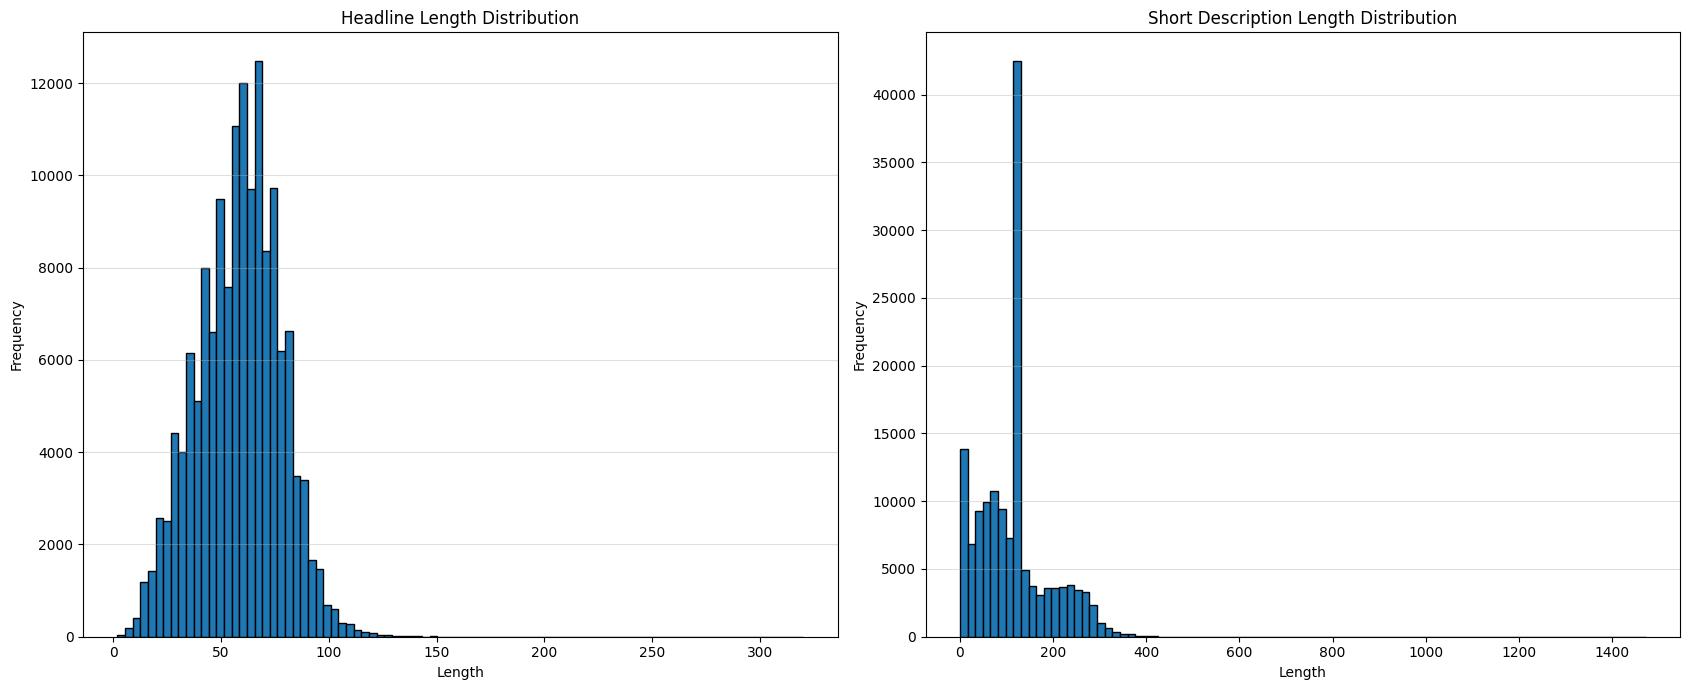

In [7]:
lengths_headline = df["headline"].str.len()
lengths_shortdescription = df["short_description"].str.len()

#1 row, 2 columns
fig, axes = plt.subplots(1, 2, figsize=(17, 7))

#Headline
axes[0].hist(lengths_headline, bins=90, range=(min(lengths_headline),max(lengths_headline)), edgecolor='black', align="mid")
axes[0].set_title('Headline Length Distribution')
axes[0].set_xlabel('Length')
axes[0].set_ylabel('Frequency')
axes[0].grid(axis='y', alpha=0.4)

#Short Description
axes[1].hist(lengths_shortdescription, bins=90, range=(min(lengths_shortdescription),max(lengths_shortdescription)), edgecolor='black', align="mid")
axes[1].set_title('Short Description Length Distribution')
axes[1].set_xlabel('Length')
axes[1].set_ylabel('Frequency')
axes[1].grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.show()

**Merging headlines and short_descriptions**

In [8]:
merged_text = []

for i in range(len(df)):
  merged_text.append(str.lower(df["headline"].iloc[i] + " " + df["short_description"].iloc[i]))

df["merged_text"] = merged_text
df

,category,headline,short_description,merged_text
2,COMEDY,23 Of The Funniest Tweets About Cats And Dogs ...,"""Until you have a dog you don't understand wha...",23 of the funniest tweets about cats and dogs ...
3,PARENTING,The Funniest Tweets From Parents This Week (Se...,"""Accidentally put grown-up toothpaste on my to...",the funniest tweets from parents this week (se...
17,SPORTS,"Maury Wills, Base-Stealing Shortstop For Dodge...","Maury Wills, who helped the Los Angeles Dodger...","maury wills, base-stealing shortstop for dodge..."
20,ENTERTAINMENT,Golden Globes Returning To NBC In January Afte...,"For the past 18 months, Hollywood has effectiv...",golden globes returning to nbc in january afte...
21,POLITICS,Biden Says U.S. Forces Would Defend Taiwan If ...,President issues vow as tensions with China rise.,biden says u.s. forces would defend taiwan if ...
...,...,...,...,...
209513,ENTERTAINMENT,'Girl With the Dragon Tattoo' India Release Ca...,"""Sony Pictures will not be releasing The Girl ...",'girl with the dragon tattoo' india release ca...
209523,SPORTS,Maria Sharapova Stunned By Victoria Azarenka I...,"Afterward, Azarenka, more effusive with the pr...",maria sharapova stunned by victoria azarenka i...
209524,SPORTS,"Giants Over Patriots, Jets Over Colts Among M...","Leading up to Super Bowl XLVI, the most talked...","giants over patriots, jets over colts among m..."
209525,SPORTS,Aldon Smith Arrested: 49ers Linebacker Busted ...,CORRECTION: An earlier version of this story i...,aldon smith arrested: 49ers linebacker busted ...


**Checking the merged_text distribution**

Min merged_text length: 4, Max merged_text length: 1487, Mean merged_text length: 174.96076803111012



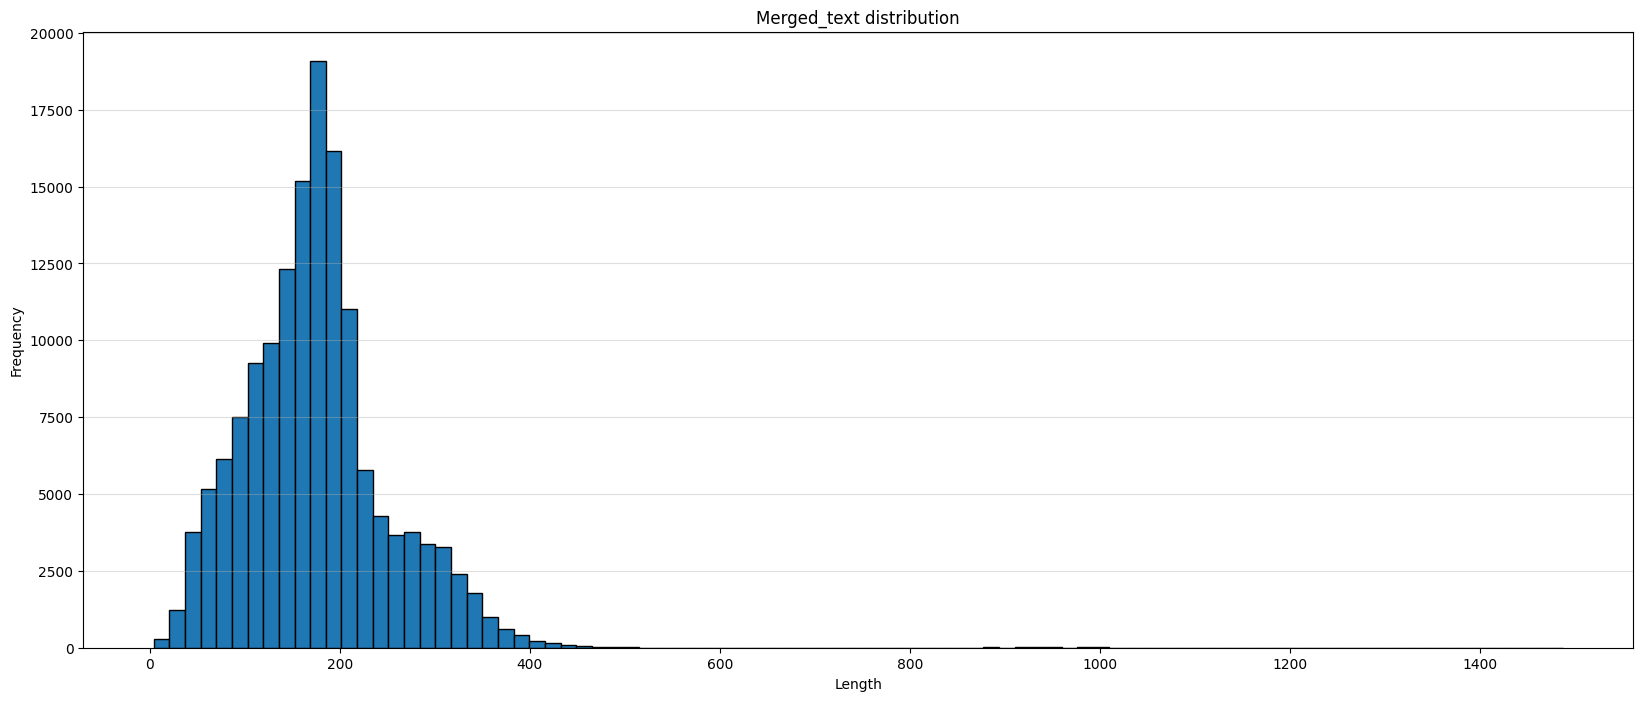

In [9]:
lengths_merged = df["merged_text"].str.len()
print(f"Min merged_text length: {min(lengths_merged)}, Max merged_text length: {max(lengths_merged)}, Mean merged_text length: {statistics.mean(lengths_merged)}\n")

plt.figure(figsize=(20,8))
lengths_merged.plot(kind='hist', bins=90, align="mid", range=(min(lengths_merged),max(lengths_merged)), edgecolor='black')
plt.title('Merged_text distribution')
plt.xlabel('Length')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.4)
plt.show()

**Creating target column by converting the categories into int and dropping useless columns**

In [10]:
#eg. POLITICS = 0, ENTERTAINMENT = 1, ...
category_to_index = {category: i for i, category in enumerate(target_names)}
df["target"] = df["category"].map(category_to_index)
df.drop(columns=["headline","short_description"], inplace=True)

**Defining the compress function to merge the merged_text of *n* rows of each given category in a single one**

In [11]:
def merge_n_rows_per_category(df, n):
    compressed_df = pd.DataFrame(columns=["category","target","merged_text"])

    #per ogni categoria ottengo tutte le istanze
    for category, group in df.groupby('category', sort=False):
        target = group['target'].iloc[0]  #ottengo il target
        group = group.reset_index(drop=True) #resetto gli indici per accederci da 0
        #suddividiamo le istanze in blocchi da n righe, se l'indice eccede si ferma da solo
        for i in range(0, len(group), n):
            n_group_block = group.iloc[i:i+n]
            merged_text = ' '.join(n_group_block['merged_text'].astype(str)) #unisco tutta la colonna in un'unica stringa
            #inserisco i dati come riga al fondo del DataFrame
            compressed_df.loc[len(compressed_df)] = [category,target,merged_text]

    return compressed_df

**Obtaining the final DataFrame and eliminating old DataFrame to save up space in RAM**

In [12]:
#final_df = merge_n_rows_per_category(df, n=100) #~1.5k instances
#final_df = merge_n_rows_per_category(df, n=50) #~3k instances
#final_df = merge_n_rows_per_category(df, n=20) #~7k instances
final_df = merge_n_rows_per_category(df, n=14) #~10k instances
del df #remove df from RAM
final_df["merged_text"].iloc[0]

'23 of the funniest tweets about cats and dogs this week (sept. 17-23) "until you have a dog you don\'t understand what could be eaten." 23 of the funniest tweets about cats and dogs this week (july 16-22) “you ever bring ur pet up to a mirror and ur like ‘that\'s you’" 20 of the funniest tweets about cats and dogs this week (june 18-24) "petition to stop ringing the doorbell on tv so my dog can lead a less confusing life" seth meyers has a field day with rudy giuliani\'s \'diet pepsi\' claim “sorry, buddy. you just gave yourself away. no one’s favorite drink is diet pepsi,” the "late night" host said. 25 of the funniest tweets about cats and dogs this week (june 4-10) "i keep hearing this ad for fresh cat food that says \'your cute kitty is descended from fierce desert cats\' and then i look at my cat and say \'this cat??\'" jimmy fallon: elon musk now owns the heavens — and twitter hell and former president donald trump goofs up the the name of his own social media operation. \'rbg\'

**Final DataFrame merged_text lenghts distributions visualization**


Min merged_text length: 366, Max merged_text length: 4776, Mean merged_text length: 2461.037880219157



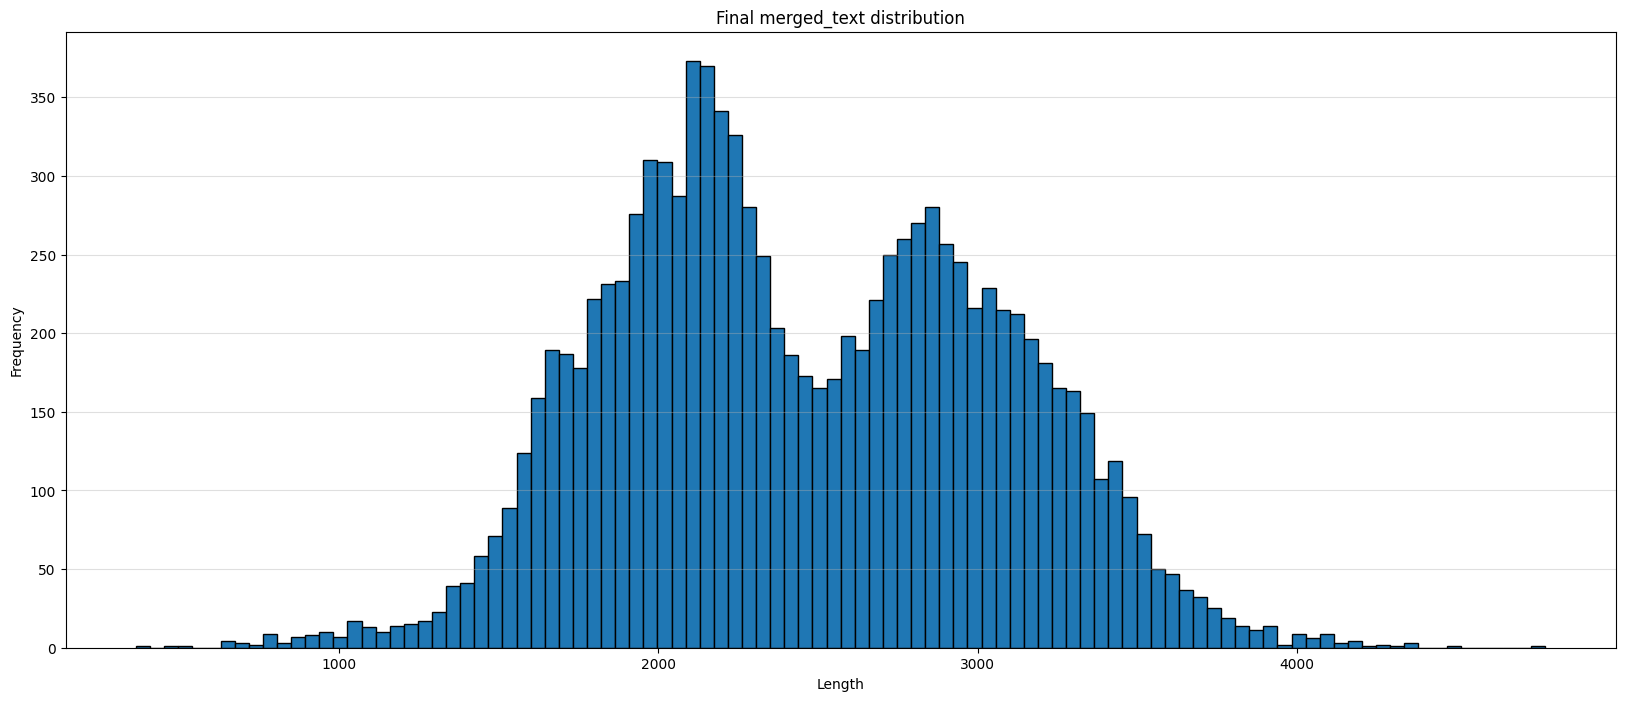

In [13]:
lengths_merged = final_df["merged_text"].str.len()
print(f"\nMin merged_text length: {min(lengths_merged)}, Max merged_text length: {max(lengths_merged)}, Mean merged_text length: {statistics.mean(lengths_merged)}\n")

plt.figure(figsize=(20,8))
lengths_merged.plot(kind='hist', bins=100, align="mid", range=(min(lengths_merged),max(lengths_merged)), edgecolor='black')
plt.title('Final merged_text distribution')
plt.xlabel('Length')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.4)
plt.show()

**Categories percentages visualization and conclusion**

,count
category,
POLITICS,2543
WELLNESS,1282
ENTERTAINMENT,1241
TRAVEL,708
STYLE & BEAUTY,701
PARENTING,628
HEALTHY LIVING,479
QUEER VOICES,454
FOOD & DRINK,453


<Axes: title={'center': 'DataFrame Categories Subdivision'}>

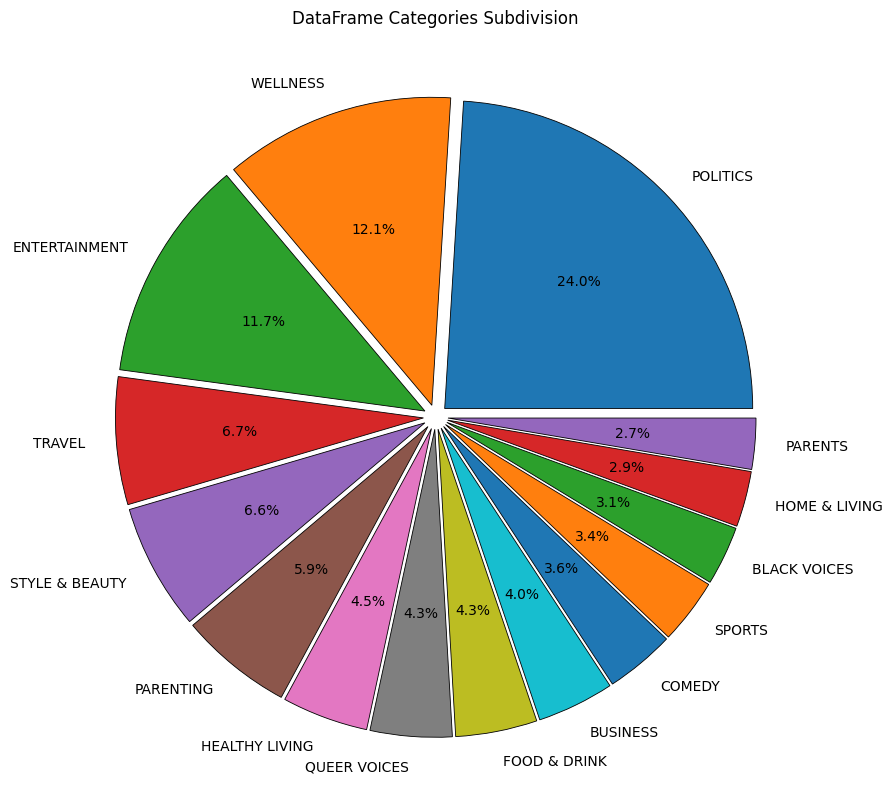

In [14]:
display(final_df.value_counts('category'))
print()
final_df.value_counts('category').plot.pie(ylabel="", figsize=(10,10), autopct='%1.1f%%', explode = np.full(len(final_df['category'].value_counts()), 0.04),
                                             wedgeprops={"edgecolor":"k",'linewidth': .6, 'linestyle': '-', 'antialiased': True}, title="DataFrame Categories Subdivision")

#Rocchio

## Rocchio algorithm

In [15]:
def rocchio(X_train, y_train, num_class, beta, gamma):
  profiles = []

  for c in range(num_class):
    start_time = time.perf_counter() #Start timing
    positive_samples = []
    negative_samples = []

    for j in range(len(X_train)):
      if y_train[j] == c:
        positive_samples.append(X_train[j])
      else:
        negative_samples.append(X_train[j])

    # Convert lists to numpy arrays (necessary for .mean(axis=0))
    positive_samples = np.asarray(positive_samples)
    negative_samples = np.asarray(negative_samples)

    pos_centroid = positive_samples.mean(axis=0)
    neg_centroid = negative_samples.mean(axis=0)

    # Rocchio formula
    prototype = beta * pos_centroid - gamma * neg_centroid
    end_time = time.perf_counter()  # End timing
    elapsed = end_time - start_time
    print(f"Iteration {c+1}/{num_class} for class: {target_names[c]} took {(elapsed/60):.6f} minutes")
    profiles.append(prototype)
  return profiles

## Rocchio prediction

In [16]:
def predict_rocchio(profiles, X_test):
    predictions = []

    for i in range(len(X_test)):
        x = X_test[i]

        best_class = None
        best_similarity = -999.0

        for c in range(len(profiles)):
            p = profiles[c]

            #input 2d array -> [[x]], [[y]]
            #return -> [[cos_sim]]
            similarity = cosine_similarity(x.reshape(1, -1), p.reshape(1, -1))[0][0]

            if similarity > best_similarity:
                best_similarity = similarity
                best_class = c

        predictions.append(best_class)

    return np.array(predictions)

#Naive hyperparameters tuning

**Converting train and test to TFIDF vectors then randomly getting the best gamma and beta based on average F1-Score on random test set**

In [17]:
best_beta, best_gamma, best_f1_score = 0,0,0
list_of_vectors = final_df["merged_text"].tolist()
target = final_df["target"].tolist()

#5 iterations to get the best gamma and beta
for i in range(0,5):
  beta = randint(1,20)
  gamma = randint(1,20)

  print(f"\033[1;31mRound: {i+1}/5\nBeta: {beta}\nGamma: {gamma}\033[0m")

  #train -> fit.transform, test -> transform
  vectorizer = TfidfVectorizer(stop_words='english')
  X_train, X_test, y_train, y_test = train_test_split(list_of_vectors, target, test_size=0.1, random_state=randint(0, 2**32 - 1))
  X_train = vectorizer.fit_transform(X_train).toarray()
  X_test = vectorizer.transform(X_test).toarray()
  profiles = rocchio(X_train, y_train, len(target_names), beta, gamma)
  predictions_tfidf = predict_rocchio(profiles, X_test)

  #Recall
  print("\nMultiClass Recall: (given everything of class x, how many i got right)")
  mc_recall = recall_score(y_test, predictions_tfidf, average=None) #labels sorted by default
  for i in range(len(target_names)):
    if mc_recall[i] > 0: print(f"  Class {target_names[i]} recall: {mc_recall[i]:.3}")
    else: print(f"  Class {target_names[i]} recall: NO INSTANCES INSIDE TEST SET!")

  #accuracy
  # accuracy = accuracy_score(y_test, predictions_tfidf)
  # print("\nAccuracy Score: ", accuracy)

  #Precision
  print("\nMultiClass Precision: (given everything i said to be of class x, how many were correct)")
  mc_precision = precision_score(y_test, predictions_tfidf, average=None) #labels sorted by default
  for i in range(len(target_names)):
    if mc_precision[i] > 0: print(f"  Class {target_names[i]} precision: {mc_precision[i]:.3}")
    else: print(f"  Class {target_names[i]} precision: NO INSTANCES INSIDE TEST SET!")

  #F1 Score
  print("\nMultiClass F1-Score:")
  mc_f1 = f1_score(y_test, predictions_tfidf, average=None) #labels sorted by default
  for i in range(len(target_names)):
    if mc_f1[i] > 0: print(f"  Class {target_names[i]} F1-Score: {mc_f1[i]:.3}")
    else: print(f"  Class {target_names[i]} F1-Score: NO INSTANCES INSIDE TEST SET!")

  #Average F1-Score
  mean_f1_score = mc_f1.mean()
  print(f"\nAverage F1-Score: {mean_f1_score:.3}")
  print("\n--------------------\n")
  if mean_f1_score > best_f1_score:
    best_f1_score = mean_f1_score
    best_beta = beta
    best_gamma = gamma

#RAM Cleanup
del list_of_vectors, target
del X_train, X_test, y_train, y_test, profiles, predictions_tfidf

Round: 1/5
Beta: 5
Gamma: 6
Iteration 1/15 for class: POLITICS took 0.132762 minutes
Iteration 2/15 for class: WELLNESS took 0.070574 minutes
Iteration 3/15 for class: ENTERTAINMENT took 0.057076 minutes
Iteration 4/15 for class: TRAVEL took 0.048887 minutes
Iteration 5/15 for class: STYLE & BEAUTY took 0.047068 minutes
Iteration 6/15 for class: PARENTING took 0.041433 minutes
Iteration 7/15 for class: HEALTHY LIVING took 0.042470 minutes
Iteration 8/15 for class: QUEER VOICES took 0.055871 minutes
Iteration 9/15 for class: FOOD & DRINK took 0.045647 minutes
Iteration 10/15 for class: BUSINESS took 0.043485 minutes
Iteration 11/15 for class: COMEDY took 0.044184 minutes
Iteration 12/15 for class: SPORTS took 0.041867 minutes
Iteration 13/15 for class: BLACK VOICES took 0.062343 minutes
Iteration 14/15 for class: HOME & LIVING took 0.046524 minutes
Iteration 15/15 for class: PARENTS took 0.048518 minutes

MultiClass Recall: (given everything of class x, how many i got right)
  Class POL

In [18]:
print(f"Best gamma: {best_gamma}, best beta: {best_beta}, with average F1-Score: {best_f1_score:.3}")

Best gamma: 5, best beta: 7, with average F1-Score: 0.932


#10-Fold CrossValidation and performances evaluation

**Shuffling final_df before cross-validation**

In [19]:
#restituisco un numero di samples uguale alla lunghezza di final_df (permuto e poi restituisco intero). Replace=False fa si che ogni riga possa essere 1 sola volta)
final_df = final_df.sample(n=len(final_df),random_state=42, replace=False)

**10-fold crossvalidation**

In [20]:
list_of_vectors = final_df["merged_text"].tolist()
target = final_df["target"].tolist()
del final_df

#accuracy_scores_tfidf = []
recall_scores_tfidf = []
precision_scores_tfidf =[]
f1_scores_tfidf = []

start_k_fold_cross_validation = time.perf_counter()
n = len(list_of_vectors)
fold_size = n // 10

for i in range(10):
  vectorizer = TfidfVectorizer(stop_words='english')
  print(f"\033[1;31mFold: {i+1}/10\033[0m")
  start_training = time.perf_counter()

  #Upper and Lower test boundaries definition
  lower = i * fold_size
  upper = (i + 1) * fold_size if i < 9 else n

  #CrossValidation dataset splits
  X_test_raw = list_of_vectors[lower:upper]
  y_test = target[lower:upper]
  X_train_raw = list_of_vectors[:lower] + list_of_vectors[upper:]
  y_train = target[:lower] + target[upper:]

  #Vectorizer
  X_train = vectorizer.fit_transform(X_train_raw).toarray()
  X_test = vectorizer.transform(X_test_raw).toarray()

  #Classes predictions
  profiles = rocchio(X_train, y_train, len(target_names), best_beta, best_gamma)
  predict_value = predict_rocchio(profiles, X_test)

  #Metrics evaluation
  #accuracy_scores_tfidf.append(accuracy_score(y_test, predict_value))
  recall_scores_tfidf.append(recall_score(y_test, predict_value, average=None))
  precision_scores_tfidf.append(precision_score(y_test, predict_value, average=None))
  f1_scores_tfidf.append(f1_score(y_test, predict_value, average=None))

  end_prediction = time.perf_counter()
  total_computation = end_prediction - start_training
  print(f"Training and predicting took a total of {(total_computation/60):.6f} minutes\n")
  print("--------------------------------------------------------------\n")

end_k_fold_cross_validation = time.perf_counter()
total_computation_k_fold_cross_validation = end_k_fold_cross_validation - start_k_fold_cross_validation
print(f"10-fold crossvalidation took a total of {(total_computation_k_fold_cross_validation/60):.6f} minutes\n")
del X_train, X_test, y_train, y_test, profiles, list_of_vectors, target



Fold: 1/10
Iteration 1/15 for class: POLITICS took 0.052383 minutes
Iteration 2/15 for class: WELLNESS took 0.055874 minutes
Iteration 3/15 for class: ENTERTAINMENT took 0.056435 minutes
Iteration 4/15 for class: TRAVEL took 0.046958 minutes
Iteration 5/15 for class: STYLE & BEAUTY took 0.055112 minutes
Iteration 6/15 for class: PARENTING took 0.047107 minutes
Iteration 7/15 for class: HEALTHY LIVING took 0.059112 minutes
Iteration 8/15 for class: QUEER VOICES took 0.049398 minutes
Iteration 9/15 for class: FOOD & DRINK took 0.054513 minutes
Iteration 10/15 for class: BUSINESS took 0.047054 minutes
Iteration 11/15 for class: COMEDY took 0.054210 minutes
Iteration 12/15 for class: SPORTS took 0.087151 minutes
Iteration 13/15 for class: BLACK VOICES took 0.051635 minutes
Iteration 14/15 for class: HOME & LIVING took 0.044132 minutes
Iteration 15/15 for class: PARENTS took 0.044357 minutes
Training and predicting took a total of 1.520954 minutes

------------------------------------------

**Final metrics**

In [21]:
#print("Average Accuracy Score: ", np.mean(accuracy_scores_tfidf))
print("\nMultiClass Recall:")
scores = np.mean(recall_scores_tfidf, axis=0)
for i in range(len(scores)):
  print(f"  Class {target_names[i]} average recall: {scores[i]:.3}")

print("\nMultiClass Precision:")
scores = np.mean(precision_scores_tfidf, axis=0)
for i in range(len(scores)):
  print(f"  Class {target_names[i]} average precision: {scores[i]:.3}")

print("\nMultiClass F1-Score:")
scores = np.mean(f1_scores_tfidf, axis=0)
for i in range(len(scores)):
  print(f"  Class {target_names[i]} average F1-Score: {scores[i]:.3}")

print(f"\nOverall F1-Score mean: {np.asarray(f1_scores_tfidf).flatten().mean():.3}")


MultiClass Recall:
  Class POLITICS average recall: 0.984
  Class WELLNESS average recall: 0.978
  Class ENTERTAINMENT average recall: 0.92
  Class TRAVEL average recall: 1.0
  Class STYLE & BEAUTY average recall: 0.997
  Class PARENTING average recall: 0.937
  Class HEALTHY LIVING average recall: 0.633
  Class QUEER VOICES average recall: 0.996
  Class FOOD & DRINK average recall: 1.0
  Class BUSINESS average recall: 0.981
  Class COMEDY average recall: 0.918
  Class SPORTS average recall: 1.0
  Class BLACK VOICES average recall: 0.956
  Class HOME & LIVING average recall: 0.983
  Class PARENTS average recall: 0.589

MultiClass Precision:
  Class POLITICS average precision: 0.985
  Class WELLNESS average precision: 0.877
  Class ENTERTAINMENT average precision: 0.985
  Class TRAVEL average precision: 1.0
  Class STYLE & BEAUTY average precision: 0.989
  Class PARENTING average precision: 0.821
  Class HEALTHY LIVING average precision: 0.904
  Class QUEER VOICES average precision: 0.9